Investigation Summary

    Objective: Identify patterns and indicators of fraudulent transactions 

•	Dataset: Financial transactions with fraud labels (highly imbalanced) 

•	Key Findings: 

        Fraud transactions are disproportionately higher for high-value amounts 
        Fraud activity peaks during late-night hours 
        Certain transaction patterns increase likelihood of fraud 
        
•	Outcome: 

        Developed a risk scoring system to flag high-risk transactions 
        Proposed actionable fraud detection rules


Investigation Questions

This investigation focuses on identifying the patterns that distinguish fraudulent transactions from legitimate ones. 
The analysis is guided by the following key questions:

1.Do fraudulent transactions exhibit different behavioral patterns compared to legitimate transactions?

2.Are high-value transactions more likely to be associated with fraud?

3.Does transaction timing influence the likelihood of fraud?

4.Are foreign transactions or location mismatches strong indicators of fraud?


Investigation Hypotheses

Based on common fraud patterns in digital payment systems, the investigation focuses on the following assumptions:

        Fraud is more likely to occur in foreign transactions or when there is a location mismatch.

        High-value transactions have a higher probability of being fraudulent

        Fraudulent transactions are more likely to occur during specific high-risk hours (e.g., late night)

        Fraud is associated with unusual transaction behavior such as rapid or irregular activity patterns

Fraud Investigation Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

df= pd.read_csv('/Users/eumch/Desktop/fraud-investigation-case-study/data/credit_card_fraud_10k.csv')
df.head()






,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [2]:
print(df.shape)
print(df.info())
print(df.isnull().sum())




(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB
None
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_

The dataset contains 10,000 transactions with 10 features, including transaction amount, time, merchant details, and behavioral indicators.

No missing values were observed
The dataset includes a binary target variable indicating whether a transaction is fraudulent

In [3]:
df.describe()


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [4]:
df['is_fraud'].value_counts(normalize=True)*100

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64

Only 1.51% of transactions are fraudulent, indicating a highly imbalanced dataset where the majority of transactions are legitimate.

This imbalance reflects real-world fraud scenarios and highlights the need for targeted detection strategies, as traditional approaches may fail to effectively identify rare fraudulent events.

Exploratory Data Analysis

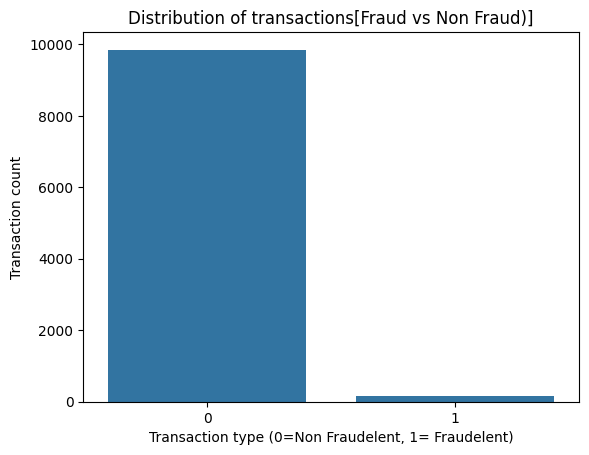

In [5]:
sns.countplot(x='is_fraud', data=df)
plt.xlabel("Transaction type (0=Non Fraudelent, 1= Fraudelent)")
plt.ylabel("Transaction count")
plt.title("Distribution of transactions[Fraud vs Non Fraud)]")

plt.show()

This class imbalance is  often observed in financial fraud detection problems and presents challenges for traditional machine learning models

##Transaction Amount Analysis

This section evaluates whether transaction amount is a significant indicator of fraud by comparing the distribution of fraudulent and non-fraudulent transactions.

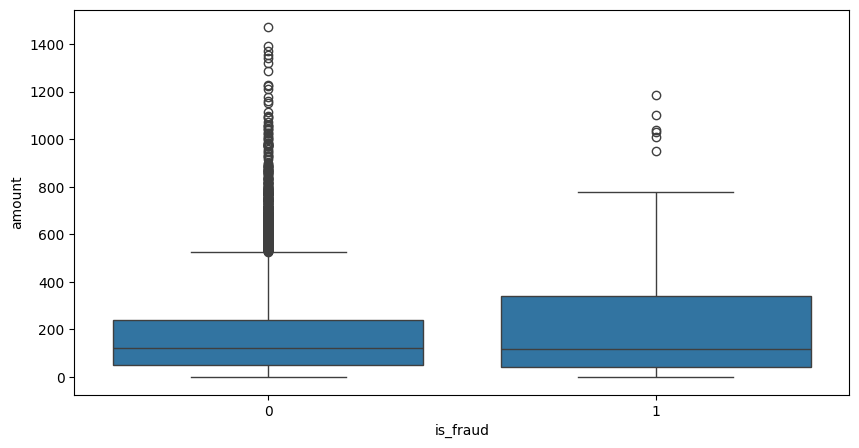

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x="is_fraud",y="amount", data=df)

plt.show()

The distribution of the amounts is different for each of the different classes. This shows that amount might be significant when investigating the fraudelent activity. Signaling a correlation between amount and fraudelent activity. This suggests transaction amount might be  a strong risk indicator

Implication: Transactions above a certain threshold should be flagged for additional verification, as they present a higher risk of fraudulent activity.

To further understand fraud patterns, we examine whether transaction timing influences the likelihood of fraudulent activity.

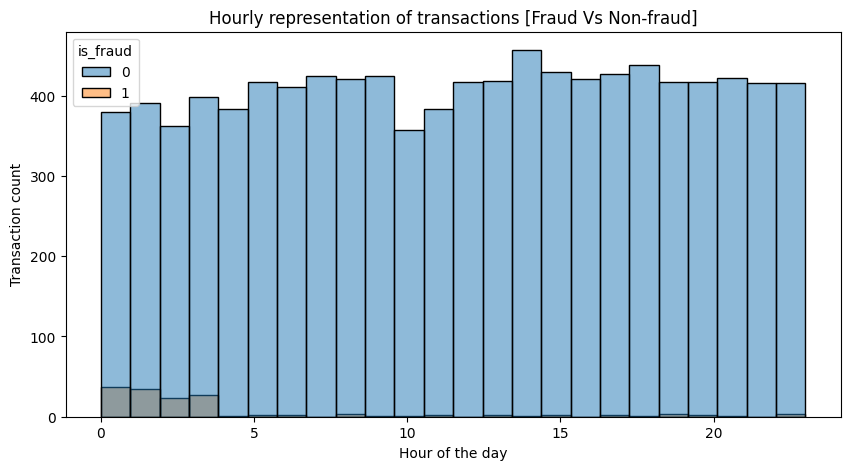

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(data=df, x="transaction_hour", hue="is_fraud", bins=24, kde= False)
plt.xlabel("Hour of the day")
plt.ylabel("Transaction count")
plt.title("Hourly representation of transactions [Fraud Vs Non-fraud]")
plt.show()

Text(0.5, 1.0, 'Rate of fraud by the hour')

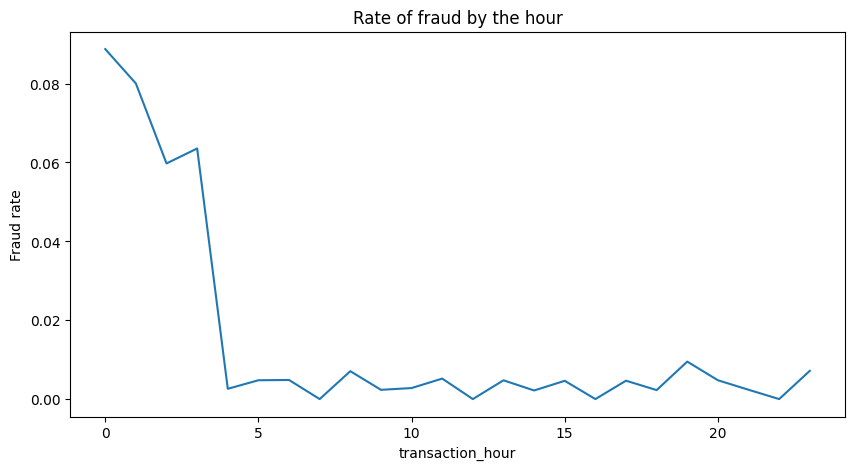

In [8]:
fraud_rate_by_hour = df.groupby("transaction_hour")["is_fraud"].mean()
plt.figure(figsize=(10,5))
fraud_rate_by_hour.plot()

plt.ylabel("Fraud rate")
plt.title("Rate of fraud by the hour")

Both the line graph and box plot show a clear concentration of fraudulent activity between 00:00 and 04:00 hours, indicating a significant time-based pattern in fraud occurrence.

This suggests that transactions occurring during late-night hours carry a higher risk of fraud compared to other periods of the day.

This implies time-based monitoring controls should be strengthened during high-risk hours (00:00–04:00), including enhanced verification checks or real-time alerts for transactions occurring within this window.




Lets try and understand  the tansactional-level features to identify any patterns that might be associated with the fraudelent activity


In [9]:
numeric_cols=[
    'amount',
    'transaction_hour',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age',
    'is_fraud'
]

corr_matrix = df[numeric_cols].corr()

Text(0.5, 1.0, 'Numerical data Correlation Heatmap')

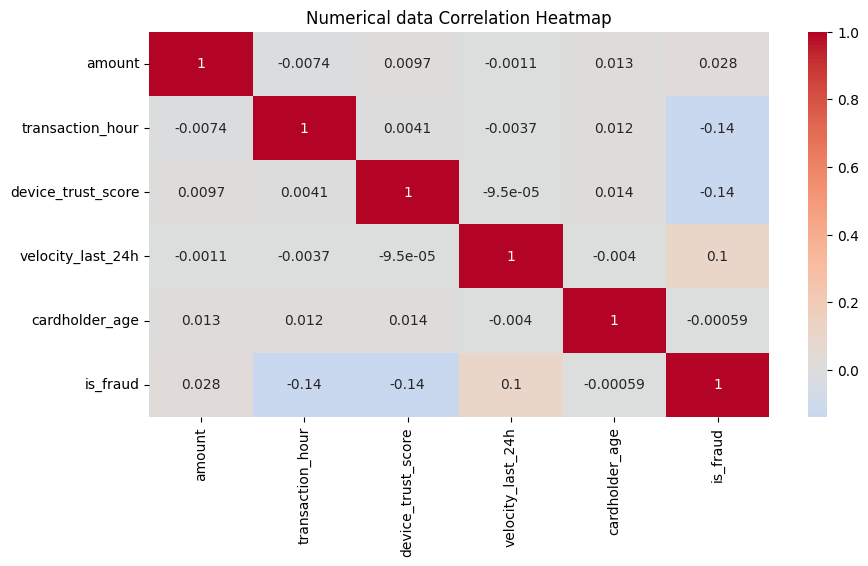

In [10]:
plt.figure(figsize=(10,5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',center=0)
plt.title('Numerical data Correlation Heatmap')

The correlation analysis shows that no single feature has a strong linear relationship with fraud, indicating that fraudulent behavior is not driven by one dominant factor.

However, some features provide useful directional insights:

Transaction hour and device trust show negative correlations with fraud, suggesting that fraud is more likely to occur during specific hours and on lower-trust devices
Transaction velocity shows a positive relationship with fraud, indicating that rapid transaction activity is a key risk signal

In contrast, cardholder age shows no meaningful relationship with fraud, suggesting that fraudulent activity is not driven by demographic factors in this dataset.

 Fraud detection should therefore rely on a combination of behavioral indicators, such as transaction timing, device trust, and activity velocity rather than any single variable.

Lets dive deeper  to the individual features

In [11]:

fraud_by_merchant=df.groupby('merchant_category')["is_fraud"].mean().sort_values(ascending=False)

fraud_by_merchant

merchant_category
Grocery        0.020062
Food           0.016722
Travel         0.014573
Electronics    0.012480
Clothing       0.011707
Name: is_fraud, dtype: float64

Text(0.5, 0, 'Rate of fraud')

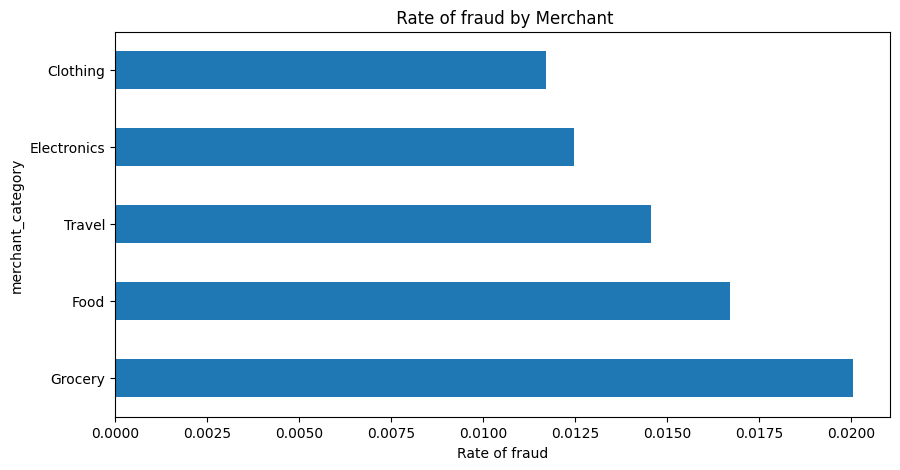

In [12]:
fraud_by_merchant.plot(kind='barh',figsize=(10,5))

plt.title(" Rate of fraud by Merchant")
plt.xlabel("Rate of fraud")

Fraud varies across the different merchant categoriesbut food and grocery show higher relative fraud rates

This may indicate that fraudsters targert transaction environments that allow for faster processing or lower scrutiny, though further investigation would be required to confirm the hypothesis.

In [13]:
df.groupby('foreign_transaction')["is_fraud"].mean()

foreign_transaction
0    0.007648
1    0.083845
Name: is_fraud, dtype: float64

Text(0.5, 1.0, 'Foreign vs Local transactions')

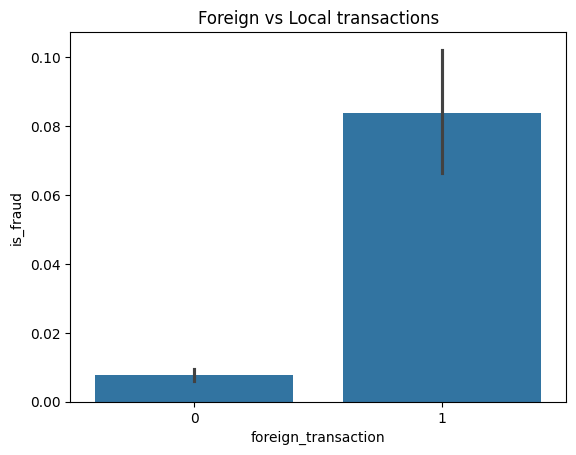

In [14]:
sns.barplot(x='foreign_transaction',y='is_fraud', data=df)

plt.title("Foreign vs Local transactions")

Foreign transactions have a higher likelihood of being fraudelent as compared to the local ones which is at per with our hypothesis.
This suggests there are addittional risks tied to foreign transactions. 
This could be  due to difference in verification controls hence increase in exposure.

In [15]:
df.groupby('location_mismatch')["is_fraud"].mean()

location_mismatch
0    0.008640
1    0.084014
Name: is_fraud, dtype: float64

Text(0.5, 1.0, 'Location Mismatch: Fraud Vs Non Fraud')

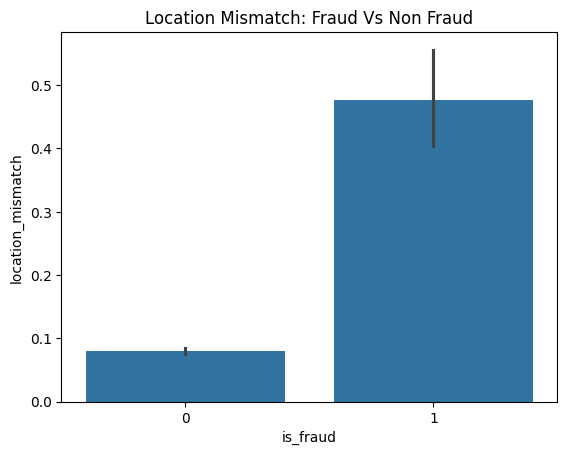

In [16]:
sns.barplot(y='location_mismatch',x='is_fraud', data=df)

plt.title("Location Mismatch: Fraud Vs Non Fraud")

The barplot shows transactions with a location mismatch are more likely to be fraudelent.
This shows geographical inconsisties between transaction origin and expected customer location, this might be as a result of unauthorized access or compromised card usage.
Signaling a probability of credit card fraud

Text(0.5, 1.0, 'Velocity_last_24h: Fraud Vs Non-Fraud')

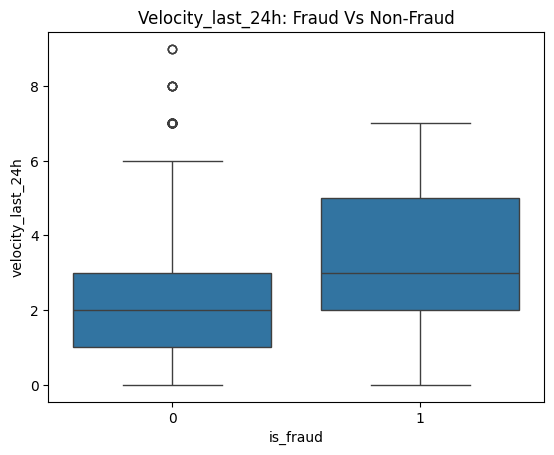

In [17]:
sns.boxplot(x="is_fraud",y="velocity_last_24h",data=df)

plt.title("Velocity_last_24h: Fraud Vs Non-Fraud")

Fraudelent transactions are more likely to occur at higher transaction velocities in comparison to the non fraudelent transactions.

This suggests fraudsters often perform rapid transaction attempts within short time windows, possibly to maximise gains.

Text(0.5, 1.0, 'Device trust score: Fraud Vs Non-Fraud')

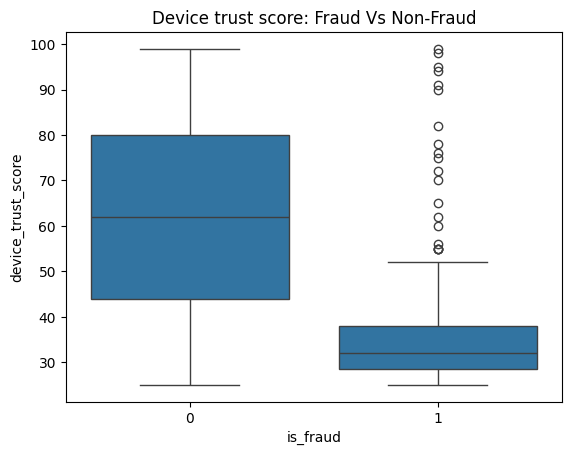

In [18]:
sns.boxplot(x="is_fraud",y="device_trust_score",data=df)

plt.title("Device trust score: Fraud Vs Non-Fraud")

As observed in the heatmap fraudelent transactions are strongly associated with lower device trust scores

This shows device profiling might be important in fraud detection.

Behavioral Insight

The analysis indicates that fraud is driven by a combination of risk signals rather than a single factor.
High risk transactions often have the following characteristics simultaneously:

        Location mismatch
        Foreign transaction indicators
        Low device trust scores
        Elevated transaction velocity

 This reinforces the need for multi layered fraud detection mechanisms and not individual rules       

Risk Scoring Model

In [19]:
print(df.groupby('location_mismatch')['is_fraud'].mean())
print(df.groupby('foreign_transaction')['is_fraud'].mean())
print(df.groupby('velocity_last_24h')['is_fraud'].mean())
print(df.groupby('device_trust_score')['is_fraud'].mean())
print(df.groupby('merchant_category')['is_fraud'].mean())

location_mismatch
0    0.008640
1    0.084014
Name: is_fraud, dtype: float64
foreign_transaction
0    0.007648
1    0.083845
Name: is_fraud, dtype: float64
velocity_last_24h
0    0.010160
1    0.007795
2    0.010518
3    0.011765
4    0.010707
5    0.115068
6    0.083969
7    0.095238
8    0.000000
9    0.000000
Name: is_fraud, dtype: float64
device_trust_score
25    0.069231
26    0.042254
27    0.070922
28    0.098485
29    0.051471
        ...   
95    0.007042
96    0.000000
97    0.000000
98    0.007246
99    0.008000
Name: is_fraud, Length: 75, dtype: float64
merchant_category
Clothing       0.011707
Electronics    0.012480
Food           0.016722
Grocery        0.020062
Travel         0.014573
Name: is_fraud, dtype: float64


In [20]:
def calculate_risk_score(row):
    score=0

    #high risk indicators
    if row['foreign_transaction']==1:
        score +=30
    if row["location_mismatch"] ==1:
        score +=30
     #Behavioral signals
    if row["velocity_last_24h"]>=5:
        score +=25
    elif row["velocity_last_24h"]>=3:
        score+=15 
     #device relationship
    if row["device_trust_score"]<40:
        score +=25
    if row["device_trust_score"]<55:
        score+=15    
   

    return score


df['risk_score']=df.apply(calculate_risk_score, axis=1)
    


Risk scores were assigned based on the relative strength of the fraud indicators observed during EDA.
Features with stronger fraud associations (location mismatch, foreign transactions) were assigned higher weights as compared to the contectual signals.

In [21]:
def classify_risk(score):
    if score>=75:
        return "High risk"
    elif score >= 40:
        return "Medium risk"
    else:
        return "Low risk"
    
df["risk_level"]  = df["risk_score"].apply(classify_risk)  

In [22]:
pd.crosstab(df["risk_level"], df["is_fraud"],normalize='index')

is_fraud,0,1
risk_level,,
High risk,0.573333,0.426667
Low risk,0.999862,0.000138
Medium risk,0.967100,0.032900


The risk scoring model effectively segments transactions based on fraud likelihood.

Low-risk transactions are almost entirely legitimate, with a fraud rate close to 0%
Medium-risk transactions show a slight increase in fraud occurrence (3%)
High-risk transactions have a significantly higher fraud rate (42%), indicating strong concentration of fraudulent activity

This demonstrates that the scoring system is effective in prioritizing high-risk transactions for further investigation.

Initially, a higher threshold (>70) resulted in a lower proportion of fraud within the high-risk category (30%).

After lowering the threshold, the proportion of fraudulent transactions in the high-risk group increased to 42%, improving the model’s ability to concentrate fraud cases.

This adjustment enhances the effectiveness of the scoring system in identifying and prioritizing suspicious transactions, though it may require balancing against potential increases in false positives.

Lets visualize the performance of the risk scoring model.

Text(0.5, 1.0, 'Fraud Distribution across risk levels')

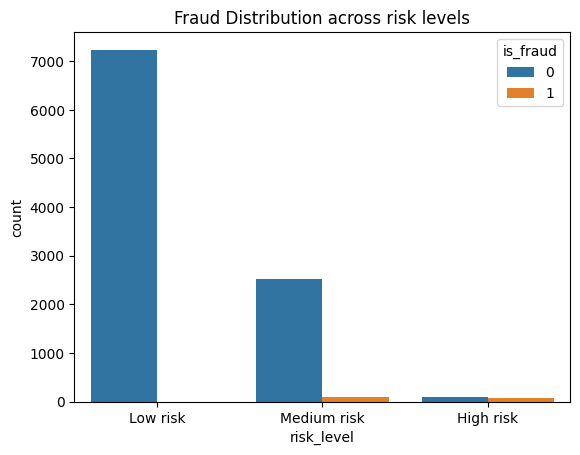

In [23]:
sns.countplot(data=df, x='risk_level', hue='is_fraud')
plt.title("Fraud Distribution across risk levels")

The model significantly improves investigation efficiency by narrowing down the pool of transactions requiring manual review to a smaller, higher-risk subset.

Conclusion

•  Fraud is primarily driven by behavioral anomalies rather than demographic characteristics. 

•  Location mismatch and foreign transactions are the strongest contextual indicators of fraud in the dataset. 

•  Fraud probability increases significantly when transaction velocity becomes unusually high, suggesting fraudsters attempt multiple transactions within short time periods.

•  Transactions originating from low device trust scores show a much higher likelihood of fraud compared to trusted devices. 

•  Fraud is not evenly distributed across merchant categories, indicating that certain transaction types are more exposed to fraud risk than others.

From the above findings we have successfully identified key behavioral fraud signals and the investigation can serve as a foundation for  building multi layered fraud detection systems as we also noticed no single factor isa strong indicator of fraudelnt activity.



Final Recommendations

Based on the analysis, the following actions are recommended to strengthen fraud detection and mitigation:

1 Implement Risk-Based Transaction Monitoring

    Deploy the risk scoring system to classify transactions into low, medium, and high-risk categories
    Prioritize investigation efforts on high-risk transactions to improve detection efficiency

2 Strengthen Controls for High-Risk Patterns

    Apply stricter verification measures for:
        Transactions occurring during high-risk hours (00:00–04:00)
        High-value transactions above defined thresholds
        Transactions with high velocity or unusual activity patterns
        Foreign transactions or those with location mismatches

3 Define Operational Actions by Risk Level

    High-risk transactions: Flag for immediate review or temporarily block pending verification
    Medium-risk transactions: Apply additional checks or monitoring
    Low-risk transactions: Process with minimal intervention to maintain efficiency

4 Improve Monitoring Efficiency

    Use the scoring system to reduce the volume of transactions requiring manual review by focusing on high-risk segments
    Continuously refine thresholds and rules based on observed fraud patterns

